<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_ML_Exam_Philine_Potgieter_u27043275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import classification_report, auc, roc_auc_score, roc_curve
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [4]:
np.random.seed(42)
n = 200
data = pd.DataFrame({
'account_age':
np.random.randint(1, 60, n),
'monthly_bill':
np.round(np.random.uniform(20, 200, n), 2),
'support_calls': np.random.randint(0, 10, n),
'contract':
np.random.randint(0, 2, n),
'churn':
np.random.choice([0, 1], n, p=[0.85, 0.15]) })
print(data.describe())
print("Churn rate:", data['churn'].mean().round(3))

       account_age  monthly_bill  support_calls    contract       churn
count   200.000000    200.000000      200.00000  200.000000  200.000000
mean     29.190000    108.494100        4.60500    0.475000    0.120000
std      16.735119     51.305718        3.00234    0.500628    0.325777
min       1.000000     20.090000        0.00000    0.000000    0.000000
25%      15.000000     66.027500        2.00000    0.000000    0.000000
50%      28.500000    102.245000        4.00000    0.000000    0.000000
75%      43.250000    148.315000        7.00000    1.000000    0.000000
max      59.000000    199.590000        9.00000    1.000000    1.000000
Churn rate: 0.12


In [5]:
churn_counts = data['churn'].value_counts()
print("Customers per churn status:")
print(churn_counts)

total_customers = len(data)
print(f"\nTotal number customers: {total_customers}")

Churn_rate = churn_counts/total_customers
print(f"\nChurn Rate by status):\n{Churn_rate.round(3)}")


Customers per churn status:
churn
0    176
1     24
Name: count, dtype: int64

Total number customers: 200

Churn Rate by status):
churn
0    0.88
1    0.12
Name: count, dtype: float64


#Question 1.2

In [6]:
mean_monthly_bill_per_churn = data.groupby('churn')['monthly_bill'].mean()
print("\nMean monthly bill per churn indicator:")
print(mean_monthly_bill_per_churn.round(2))


Mean monthly bill per churn indicator:
churn
0    109.10
1    104.07
Name: monthly_bill, dtype: float64


# Question 2.2

In [7]:
X = data[['account_age','monthly_bill', 'support_calls', 'contract']].values
y = data['churn'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SGDClassifier(loss='log_loss', learning_rate='optimal',
max_iter=200, random_state=42)
clf.fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.43      0.57        35
           1       0.09      0.40      0.15         5

    accuracy                           0.42        40
   macro avg       0.46      0.41      0.36        40
weighted avg       0.74      0.42      0.51        40



# Question 4.2

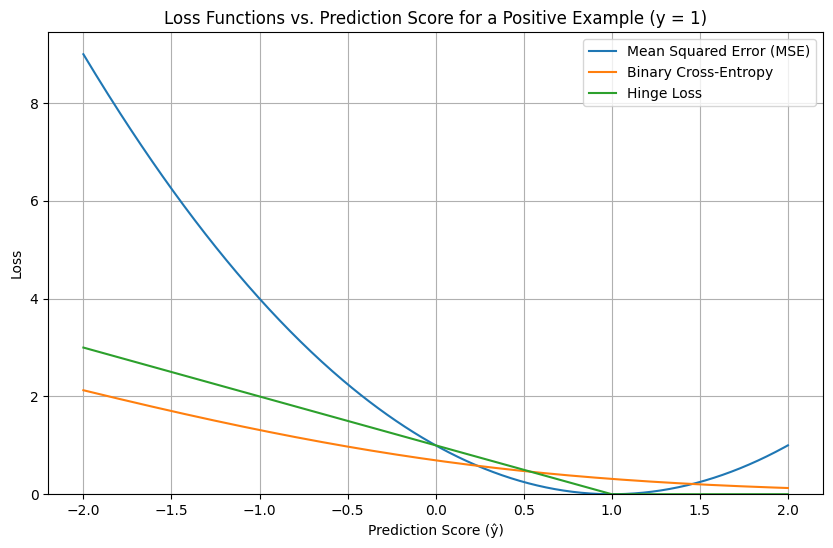

In [14]:
y_hat = np.linspace(-2, 2, 400)

y = 1
mse_loss = (y - y_hat)**2
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

p = sigmoid(y_hat)
p = np.clip(p, 1e-10, 1 - 1e-10)

bce_loss = - (y * np.log(p) + (1 - y) * np.log(1 - p))

# Hinge Loss
hinge_loss = np.maximum(0, 1 - y * y_hat)

# Plots
plt.figure(figsize=(10, 6))
plt.plot(y_hat, mse_loss, label='Mean Squared Error (MSE)')
plt.plot(y_hat, bce_loss, label='Binary Cross-Entropy')
plt.plot(y_hat, hinge_loss, label='Hinge Loss')

plt.xlabel('Prediction Score (ŷ)')
plt.ylabel('Loss')
plt.title('Loss Functions vs. Prediction Score for a Positive Example (y = 1)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

#Question 5.1

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
probability=True, random_state=42)
svm.fit(X_train, y_train)

proba = svm.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"RBF-SVM AUC: {auc:.3f}")
print(f"Support vectors per class: {svm.n_support_}")

RBF-SVM AUC: 0.069
Support vectors per class: [48 19]


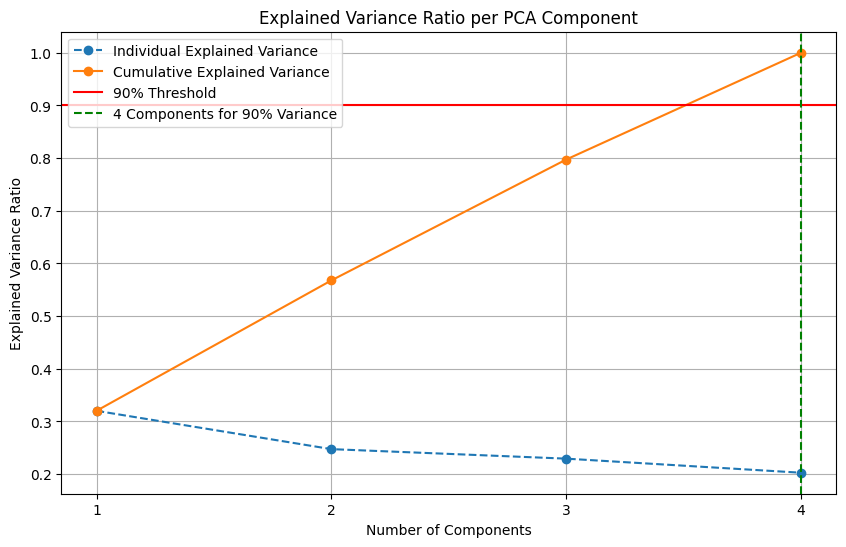

Minimum number needed: 4


In [10]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train)

# explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumsum_explained_variance = np.cumsum(explained_variance_ratio)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumsum_explained_variance, marker='o', linestyle='-', label='Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per PCA Component')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold')

# minimum for 90% variance
min_components_90_percent = np.where(cumsum_explained_variance >= 0.90)[0][0] + 1
plt.axvline(x=min_components_90_percent, color='g', linestyle='--', label=f'{min_components_90_percent} Components for 90% Variance')
plt.xticks(range(1, len(explained_variance_ratio) + 1))

plt.legend()
plt.show()

print(f"Minimum number needed: {min_components_90_percent}")

In [11]:
explained_variance_df = pd.DataFrame({
    'Component': range(1, len(explained_variance_ratio) + 1),
    'Individual Explained Variance': explained_variance_ratio,
    'Cumulative Explained Variance': cumsum_explained_variance
})
print("Explained Variance per Component:")
print(explained_variance_df.to_string(index=False))


Explained Variance per Component:
 Component  Individual Explained Variance  Cumulative Explained Variance
         1                       0.320266                       0.320266
         2                       0.247532                       0.567798
         3                       0.229457                       0.797255
         4                       0.202745                       1.000000


#Question 6.2

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

ridge_lr = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
ridge_lr.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

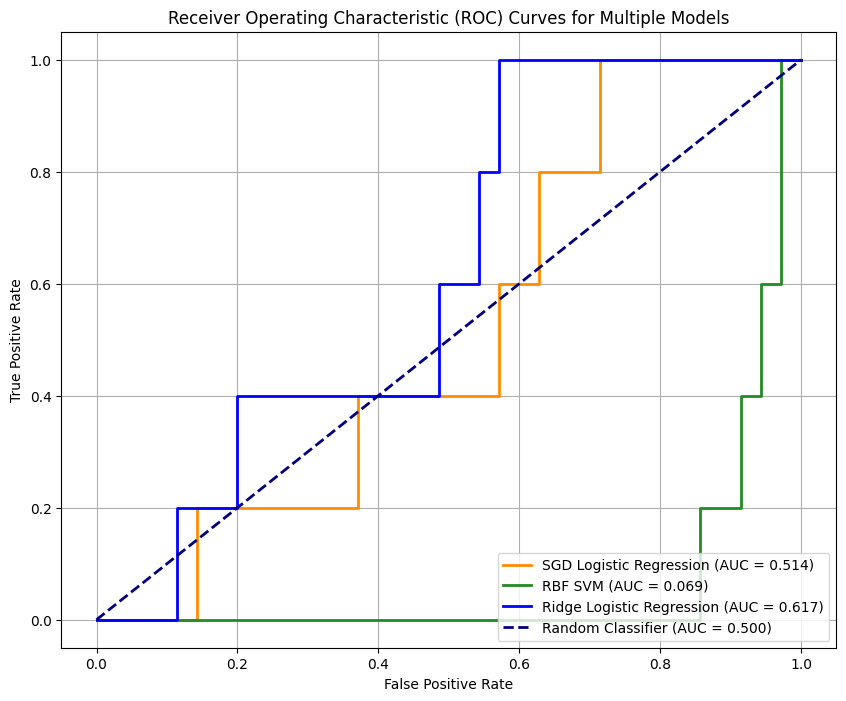

SGD Logistic Regression AUC: 0.514
RBF SVM AUC: 0.069
Ridge Logistic Regression AUC: 0.617


In [13]:
# ROC/AUC for all models

# SGD Logistic Regression
sgd_proba = clf.predict_proba(X_test)[:, 1]
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, sgd_proba)
auc_sgd = auc(fpr_sgd, tpr_sgd)

# RBF SVM
svm_proba = svm.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
auc_svm = auc(fpr_svm, tpr_svm)

# Ridge Logistic Regression
ridge_lr_proba = ridge_lr.predict_proba(X_test)[:, 1]
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, ridge_lr_proba)
auc_ridge = auc(fpr_ridge, tpr_ridge)

# ROC Curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_sgd, tpr_sgd, color='darkorange', lw=2, label=f'SGD Logistic Regression (AUC = {auc_sgd:.3f})')
plt.plot(fpr_svm, tpr_svm, color='forestgreen', lw=2, label=f'RBF SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_ridge, tpr_ridge, color='blue', lw=2, label=f'Ridge Logistic Regression (AUC = {auc_ridge:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multiple Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"SGD Logistic Regression AUC: {auc_sgd:.3f}")
print(f"RBF SVM AUC: {auc_svm:.3f}")
print(f"Ridge Logistic Regression AUC: {auc_ridge:.3f}")